# Analsis descriptivo y predictivo sobre Indice de Precios al Consumidor Nacional, Serie Mensual, 1984-2026 en la Republica Dominicana. 📉📈

In [237]:
# Librerias que seran utilizadas para el analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Para el analisis predictivo con el modelo ARIMA O SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [238]:
# Importamos los datos
df = pd.DataFrame(pd.read_excel(r'/content/ipc_base_2019-2020.xls'))
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,"Indice de Precios al Consumidor Nacional, Seri...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Serie Empalmada Oficial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Base Anual: Octubre 2019 - Septiembre 2020=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Período,NaN,Indice,Variación Porcentual,NaN,NaN,Promedio,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Mensual,con Dic.,12 meses,12 meses,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
553,NaN,Febrero,137.7744,0.02541,0.421953,4.672386,4.105318,NaN,NaN,NaN,NaN
554,NaN,Marzo,138.1495,0.272257,0.695358,4.629146,4.192814,NaN,NaN,NaN,NaN
555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza de los datos 📊

In [239]:
# pasar la data a una copia
ipc = df.copy(
  deep=True
) # de esta forma podemos hacer cambio en nuestro dataframe IPC y ver los cambios

In [240]:
# Eliminamos las primeras 3 filas del dataframe
ipc = ipc.iloc[3:]

In [241]:
ipc

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
3,Período,NaN,Indice,Variación Porcentual,NaN,NaN,Promedio,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,Mensual,con Dic.,12 meses,12 meses,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878,NaN,NaN,NaN,NaN
7,NaN,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
553,NaN,Febrero,137.7744,0.02541,0.421953,4.672386,4.105318,NaN,NaN,NaN,NaN
554,NaN,Marzo,138.1495,0.272257,0.695358,4.629146,4.192814,NaN,NaN,NaN,NaN
555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [242]:
# Eliminacion de la columnas
ipc.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10'],
      dtype='object')

In [243]:
# Eliminacion de las columnas que estan vacias
ipc = ipc.drop(columns= ['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10'])
ipc.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
3,Período,NaN,Indice,Variación Porcentual,NaN,NaN,Promedio
4,NaN,NaN,NaN,Mensual,con Dic.,12 meses,12 meses
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878
7,NaN,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967


In [244]:
ipc = ipc.iloc[3:]
ipc.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878
7,NaN,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967
8,NaN,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152
9,NaN,Abril,1.458127,1.567587,7.545965,14.879978,7.359019
10,NaN,Mayo,1.475611,1.199098,8.835546,15.22033,8.260218


In [245]:
ipc.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [246]:
# Corregimos las columnas
columnas_corregidas = {
    'Unnamed: 0': 'AÑOS',
    'Unnamed: 1': 'MES',
    'Unnamed: 2': 'INDICE_PRECIOS_CONSUMIDORES_NACIONAL',
    'Unnamed: 3': 'VARIACION_PORCENTUAL_MENSUAL',
    'Unnamed: 4': 'VARIACION_PORCENTUAL_CON_DIC',
    'Unnamed: 5': 'VARIACION_PORCENTUAL_A_12_MESES',
    'Unnamed: 6': 'PROMEDIO_12_MESES'

}

ipc = ipc.rename(columns=columnas_corregidas)
ipc.head()

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878
7,NaN,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967
8,NaN,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152
9,NaN,Abril,1.458127,1.567587,7.545965,14.879978,7.359019
10,NaN,Mayo,1.475611,1.199098,8.835546,15.22033,8.260218


In [247]:
ipc['MES'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre', nan,
       'Noviembre ', 'Diciembre ', 'Marzo ', 'Agosto ', 'Septiembre ',
       'Octubre '], dtype=object)

In [248]:
# Ahora corregimos nuestra variable años
ipc = ipc.dropna(how='all').copy()
# Completamos hacia abajo en cambio de cada año
ipc['AÑOS'] = ipc['AÑOS'].ffill()


In [249]:
ipc[ipc['AÑOS'] == 2022].head(12) # Verificamos si tenemos el problema corregido

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES
500,2022,Enero,114.602,1.182204,1.182204,8.726424,8.449462
501,2022,Febrero,115.658,0.92145,2.114548,8.98383,8.606274
502,2022,Marzo,116.431,0.66835,2.79703,9.05455,8.669991
503,2022,Abril,117.544,0.955931,3.779699,9.643117,8.677224
504,2022,Mayo,118.122,0.491731,4.290015,9.472572,8.604965
505,2022,Junio,118.877,0.63917,4.956605,9.478289,8.623919
506,2022,Julio,119.468,0.497153,5.4784,9.434999,8.753508
507,2022,Agosto,119.718,0.209261,5.699125,8.795972,8.825656
508,2022,Septiembre,120.07,0.294024,6.009906,8.626227,8.895424
509,2022,Octubre,120.405,0.279004,6.305678,8.235051,8.932924


In [250]:
# Ahora eliminar las filas en blancos de nuestro dataframe
ipc = ipc.dropna()
ipc.isnull().sum()

,0
AÑOS,0
MES,0
INDICE_PRECIOS_CONSUMIDORES_NACIONAL,0
VARIACION_PORCENTUAL_MENSUAL,0
VARIACION_PORCENTUAL_CON_DIC,0
VARIACION_PORCENTUAL_A_12_MESES,0
PROMEDIO_12_MESES,0


In [251]:
# Correcion de la variables mes
ipc['MES'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre',
       'Noviembre ', 'Diciembre ', 'Marzo ', 'Agosto ', 'Septiembre ',
       'Octubre '], dtype=object)

In [252]:
# Normalizacion de los datos para la variable mes
normalizacion_meses = {
    'Enero': 'Enero',
    'Febrero': 'Febrero',
    'Marzo': 'Marzo',
    'Marzo ': 'Marzo',
    'Abril': 'Abril',
    'Mayo': 'Mayo',
    'Junio': 'Junio',
    'Julio': 'Julio',
    'Agosto': 'Agosto',
    'Agosto ': 'Agosto',
    'Septiembre': 'Septiembre',
    'Septiembre ': 'Septiembre',
    'Octubre': 'Octubre',
    'Octubre ': 'Octubre',
    'Noviembre': 'Noviembre',
    'Noviembre ': 'Noviembre',
    'Diciembre': 'Diciembre',
    'Diciembre ': 'Diciembre'
}

ipc['MES'] = ipc['MES'].map(normalizacion_meses)
ipc['MES'].unique().tolist()

['Enero',
 'Febrero',
 'Marzo',
 'Abril',
 'Mayo',
 'Junio',
 'Julio',
 'Agosto',
 'Septiembre',
 'Octubre',
 'Noviembre',
 'Diciembre']

In [253]:
ipc.head(24)

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878
7,1984,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967
8,1984,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152
9,1984,Abril,1.458127,1.567587,7.545965,14.879978,7.359019
10,1984,Mayo,1.475611,1.199098,8.835546,15.22033,8.260218
11,1984,Junio,1.539143,4.30549,13.52145,19.615229,9.488436
12,1984,Julio,1.559051,1.293443,14.989785,20.740046,10.800322
13,1984,Agosto,1.566149,0.455252,15.513279,20.130129,12.012154
14,1984,Septiembre,1.639548,4.686636,20.926966,24.815498,13.650065
15,1984,Octubre,1.677979,2.343997,23.761491,26.309617,15.40434


In [254]:
# Pasamos nuestra variable año a tipo entero
ipc['AÑOS'] = pd.to_numeric(ipc['AÑOS'], errors='coerce').astype('Int64')
ipc.head()

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES
6,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878
7,1984,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967
8,1984,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152
9,1984,Abril,1.458127,1.567587,7.545965,14.879978,7.359019
10,1984,Mayo,1.475611,1.199098,8.835546,15.22033,8.260218


In [255]:
# Comprobamos si tenemos datos faltantes
ipc.isnull().sum()

,0
AÑOS,11
MES,0
INDICE_PRECIOS_CONSUMIDORES_NACIONAL,0
VARIACION_PORCENTUAL_MENSUAL,0
VARIACION_PORCENTUAL_CON_DIC,0
VARIACION_PORCENTUAL_A_12_MESES,0
PROMEDIO_12_MESES,0


In [256]:
# Buscamos las 11 filas de los datos faltantes
filas_con_nan = ipc[ipc.isnull().any(axis=1)]
filas_con_nan

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES
163,<NA>,Febrero,17.314712,0.126134,0.049014,7.193381,11.251472
164,<NA>,Marzo,17.339121,0.140972,0.190055,6.473834,10.59681
165,<NA>,Abril,17.360413,0.122802,0.313091,6.753247,10.091423
166,<NA>,Mayo,17.399883,0.227354,0.541157,6.542294,9.626606
167,<NA>,Junio,17.459607,0.343243,0.886257,6.236833,9.163457
168,<NA>,Julio,17.504443,0.256799,1.145332,5.810826,8.628716
169,<NA>,Agosto,17.53266,0.161201,1.308379,4.801374,8.0126
170,<NA>,Septiembre,17.628392,0.546016,1.86154,3.767259,7.290903
171,<NA>,Octubre,17.668554,0.227826,2.093607,3.255569,6.572637
172,<NA>,Noviembre,17.784366,0.655471,2.762801,2.986346,5.831412


In [257]:
# Creamos una variable/columna con los meses el numeros enteros
meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

ipc['MES_NUM'] = ipc['MES'].map(meses)

In [258]:
# Filtramos el año 1996 que la cual es que sigue y sus filas estan incorrectas
filas_con_nan = ipc[ipc['AÑOS'] == 1996]
filas_con_nan

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES,MES_NUM
162,1996,Enero,17.2929,-0.077022,-0.077022,7.477621,11.869766,1


In [259]:
# Reparamos las filas
ipc['AÑOS'] = ipc['AÑOS'].fillna(1996)

In [260]:
# Verificamos el cambio
ipc[ipc['AÑOS'] == 1996]

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES,MES_NUM
162,1996,Enero,17.2929,-0.077022,-0.077022,7.477621,11.869766,1
163,1996,Febrero,17.314712,0.126134,0.049014,7.193381,11.251472,2
164,1996,Marzo,17.339121,0.140972,0.190055,6.473834,10.59681,3
165,1996,Abril,17.360413,0.122802,0.313091,6.753247,10.091423,4
166,1996,Mayo,17.399883,0.227354,0.541157,6.542294,9.626606,5
167,1996,Junio,17.459607,0.343243,0.886257,6.236833,9.163457,6
168,1996,Julio,17.504443,0.256799,1.145332,5.810826,8.628716,7
169,1996,Agosto,17.53266,0.161201,1.308379,4.801374,8.0126,8
170,1996,Septiembre,17.628392,0.546016,1.86154,3.767259,7.290903,9
171,1996,Octubre,17.668554,0.227826,2.093607,3.255569,6.572637,10


In [261]:
# Vericamos que no tengamos datos vacios nuevamente
ipc.isnull().sum()

,0
AÑOS,0
MES,0
INDICE_PRECIOS_CONSUMIDORES_NACIONAL,0
VARIACION_PORCENTUAL_MENSUAL,0
VARIACION_PORCENTUAL_CON_DIC,0
VARIACION_PORCENTUAL_A_12_MESES,0
PROMEDIO_12_MESES,0
MES_NUM,0


In [262]:
# Verificamos a traves de los años que sigue el orden con los meses
ipc[(ipc["AÑOS"] == 1995) | (ipc["AÑOS"] == 1996)]

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES,MES_NUM
149,1995,Enero,16.089768,1.539302,1.539302,15.267942,9.324274,1
150,1995,Febrero,16.152781,0.391634,1.936964,14.467276,10.21797,2
151,1995,Marzo,16.284866,0.817722,2.770525,14.219281,10.941715,3
152,1995,Abril,16.262188,-0.139257,2.62741,12.756866,11.401414,4
153,1995,Mayo,16.331433,0.425804,3.064402,12.081358,11.738936,5
154,1995,Junio,16.434608,0.631757,3.715519,11.785416,12.029019,6
155,1995,Julio,16.543149,0.660445,4.400503,12.318704,12.389605,7
156,1995,Agosto,16.729418,1.125959,5.576009,12.289977,12.640579,8
157,1995,Septiembre,16.988395,1.548029,7.210357,12.525943,12.844386,9
158,1995,Octubre,17.111478,0.724512,7.987109,11.994108,12.933456,10


# ***Analisis estadistico de los datos tanto prediccion como descriptivo***📉📈📊

In [263]:
inflacion_luis = ipc.query("2020 <= AÑOS <= 2026").groupby('AÑOS')['VARIACION_PORCENTUAL_MENSUAL'].mean().reset_index()
inflacion_luis['GOBIERNO'] = 'Luis Abinader'

inflacion_danilo = ipc.query("2012 <= AÑOS <= 2020").groupby('AÑOS')['VARIACION_PORCENTUAL_MENSUAL'].mean().reset_index()
inflacion_danilo['GOBIERNO'] = 'Danilo Medina'

comparacion_inflacion = pd.concat([inflacion_luis, inflacion_danilo])

/tmp/ipykernel_26563/1358537669.py:1: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.

/tmp/ipykernel_26563/1358537669.py:4: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



In [264]:
fig = px.line(
    comparacion_inflacion,
    x='AÑOS',
    y='VARIACION_PORCENTUAL_MENSUAL',
    color='GOBIERNO',
    markers=True,
    title='Comparación de Inflación Promedio por Gobierno'
)

fig.show()

### ***Interpretacion grafica:*** 📈📉📊

En la grafica nos damos cuenta que en el gobiernos de **Danilo Medina** Tenemos un grafica estable en el promedio mensual del ipc, mientras tanto para el gobierno de luis abinader pospandemia hubo un alto aumento del ipc, donde para finales del del 2023 se va regulando donde el punto mas alto es 2021 con 68% al mes anterior.

# ***Analisis predictivo de la variable IPC mensual para mayo 2026*** 📈📊📉

In [265]:
# Preparando la variable fecha para el modelo
ipc['FECHA'] = pd.to_datetime(
    ipc['AÑOS'].astype(str) + '-' + ipc['MES_NUM'].astype(str)
)

ipc = ipc.sort_values(by='FECHA', ascending=True)
ipc.set_index(
    'FECHA', inplace=True
)

In [267]:
# Confirmamos nuestra nueva variable fecha
ipc

,AÑOS,MES,INDICE_PRECIOS_CONSUMIDORES_NACIONAL,VARIACION_PORCENTUAL_MENSUAL,VARIACION_PORCENTUAL_CON_DIC,VARIACION_PORCENTUAL_A_12_MESES,PROMEDIO_12_MESES,MES_NUM
FECHA,,,,,,,,
1984-01-01,1984,Enero,1.37936,1.736466,1.736466,7.053607,5.570878,1
1984-02-01,1984,Febrero,1.418138,2.811245,4.596527,11.183496,6.007967,2
1984-03-01,1984,Marzo,1.435622,1.23291,5.886108,11.916329,6.516152,3
1984-04-01,1984,Abril,1.458127,1.567587,7.545965,14.879978,7.359019,4
1984-05-01,1984,Mayo,1.475611,1.199098,8.835546,15.22033,8.260218,5
...,...,...,...,...,...,...,...,...
2025-11-01,2025,Noviembre,136.0551,0.714562,4.079726,4.811116,3.738191,11
2025-12-01,2025,Diciembre,137.1955,0.83819,4.952112,4.952112,3.873118,12
2026-01-01,2026,Enero,137.7394,0.396442,0.396442,4.983979,4.012525,1


In [268]:
# Preparacion de nuestro modelo
serie = ipc['VARIACION_PORCENTUAL_MENSUAL']
# Le decimos que nuestra frecuencia sera mensual aunque no esta variable esta enfocado a mes
serie = serie.asfreq('MS')

In [273]:
# Confirmamos la estacionaridad de la serie
resultado = adfuller(serie)
print(f'ADF Statistic: {resultado[0]}')
print(f'p-value: {resultado[1]}')

ADF Statistic: -4.903955177608815
p-value: 3.426138713391962e-05


In [274]:
rolling_mean = serie.rolling(window=12).mean()
rolling_std = serie.rolling(window=12).std()

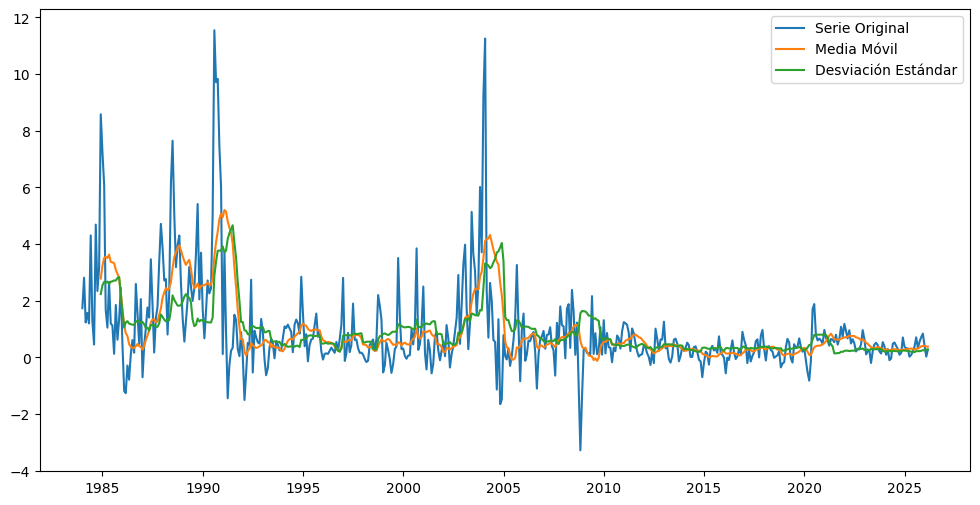

In [275]:
plt.figure(figsize=(12,6))

plt.plot(serie, label='Serie Original')
plt.plot(rolling_mean, label='Media Móvil')
plt.plot(rolling_std, label='Desviación Estándar')

plt.legend()
plt.show()

In [270]:
! pip install pmdarima # Instalacion de la libreria

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00


In [272]:
# utilizamos la libreria from pmdarima import auto_arima para diversas pruebas automaticas para nuestro modelo diferentes combinaciones
from pmdarima import auto_arima

In [276]:
auto_arima(serie, seasonal=True, m=12, trace=True, suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=5.82 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1661.178, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1642.987, Time=1.32 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1627.282, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1659.180, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1631.310, Time=0.35 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=1625.834, Time=2.41 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1627.430, Time=0.33 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=inf, Time=3.43 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=5.08 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1629.153, Time=1.44 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=1629.393, Time=0.74 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=inf, Time=4.50 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1657.398, Time=0.78 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : 

ARIMA(order=(1, 1, 1), scoring_args={}, seasonal_order=(0, 0, 1, 12),
      suppress_warnings=True, with_intercept=False)

In [280]:
print(serie.dtype)
print(serie.head())

object
FECHA
1984-01-01    1.736466
1984-02-01    2.811245
1984-03-01     1.23291
1984-04-01    1.567587
1984-05-01    1.199098
Freq: MS, Name: VARIACION_PORCENTUAL_MENSUAL, dtype: object


In [281]:
# ahora pasamos nuestra serie a valores numericos para que ARIMA reconozca
serie = pd.to_numeric(serie, errors='coerce')

In [282]:
# Ahora hacemos nuestro modelo
modelo = ARIMA(serie, order=(1, 1, 1))
modelo_entrenado = modelo.fit()
print(modelo_entrenado.summary())

                                    SARIMAX Results                                     
Dep. Variable:     VARIACION_PORCENTUAL_MENSUAL   No. Observations:                  507
Model:                           ARIMA(1, 1, 1)   Log Likelihood                -785.969
Date:                          Thu, 07 May 2026   AIC                           1577.937
Time:                                  00:28:59   BIC                           1590.617
Sample:                              01-01-1984   HQIC                          1582.910
                                   - 03-01-2026                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6491      0.024     27.302      0.000       0.602       0.696
ma.L1         -0.9772      0.011    -86.876      0.

In [283]:
# Ahora vemos nuestras predicciones a 12 meses del IPC_VARIACION_PORCENTUAL_MENSUAL
prediccion = modelo_entrenado.forecast(steps=12)
print(prediccion)

2026-04-01    0.309721
2026-05-01    0.334039
2026-06-01    0.349824
2026-07-01    0.360069
2026-08-01    0.366720
2026-09-01    0.371036
2026-10-01    0.373838
2026-11-01    0.375657
2026-12-01    0.376837
2027-01-01    0.377603
2027-02-01    0.378101
2027-03-01    0.378423
Freq: MS, Name: predicted_mean, dtype: float64


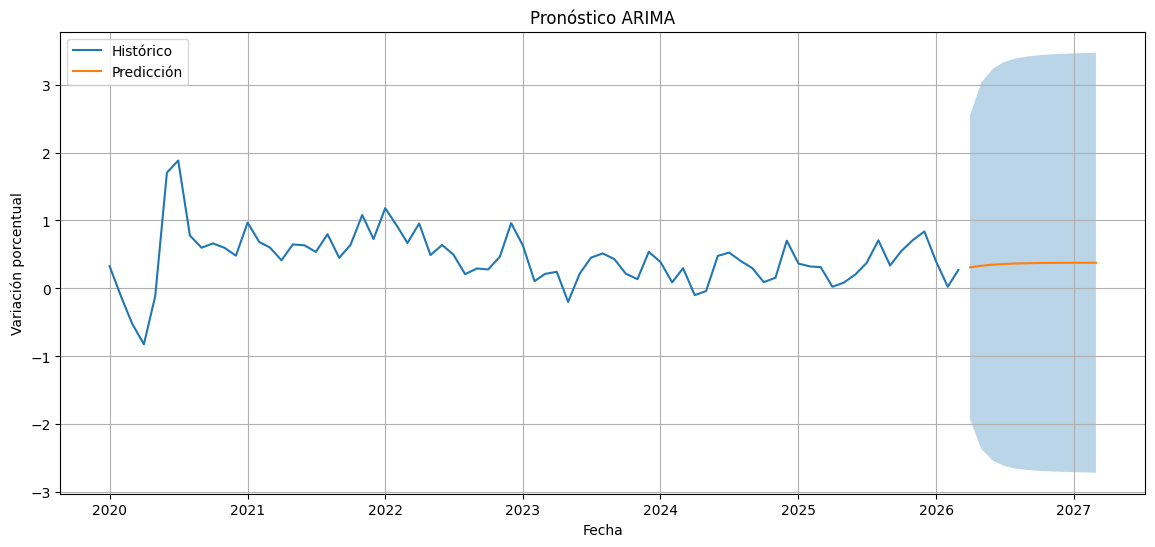

In [287]:
# =========================
# Forecast
# =========================

forecast = modelo_entrenado.get_forecast(steps=12)

predicciones = forecast.predicted_mean
intervalos = forecast.conf_int()

# =========================
# Mostrar histórico SOLO desde 2020
# =========================

historico_2020 = ipc.loc['2020-01-01':]

# =========================
# Gráfica
# =========================

plt.figure(figsize=(14,6))

# Histórico desde 2020
plt.plot(
    historico_2020.index,
    historico_2020['VARIACION_PORCENTUAL_MENSUAL'],
    label='Histórico'
)

# Predicciones futuras
plt.plot(
    predicciones.index,
    predicciones,
    label='Predicción'
)

# Intervalos de confianza
plt.fill_between(
    predicciones.index,
    intervalos.iloc[:,0],
    intervalos.iloc[:,1],
    alpha=0.3
)

plt.title('Pronóstico ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Variación porcentual')

plt.legend()
plt.grid(True)

plt.show()

In [288]:
# Modelo sarimax para seguir la oscilacion de la grafica
from statsmodels.tsa.statespace.sarimax import SARIMAX
mdoelo_1 = SARIMAX(serie, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
modelo_entrenado_1 = mdoelo_1.fit()
print(modelo_entrenado_1.summary())

                                     SARIMAX Results                                      
Dep. Variable:       VARIACION_PORCENTUAL_MENSUAL   No. Observations:                  507
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -783.344
Date:                            Thu, 07 May 2026   AIC                           1576.687
Time:                                    01:02:31   BIC                           1597.700
Sample:                                01-01-1984   HQIC                          1584.937
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6643      0.024     27.702      0.000       0.617       0.711
ma.L1         -0.9913      0.016   

In [289]:
prediccion_1 = modelo_entrenado_1.forecast(steps=12)
print(prediccion_1)

2026-04-01    0.042898
2026-05-01   -0.051511
2026-06-01    0.320644
2026-07-01    0.242017
2026-08-01    0.245329
2026-09-01    0.254624
2026-10-01    0.206904
2026-11-01    0.110896
2026-12-01    0.319934
2027-01-01    0.351290
2027-02-01    0.038718
2027-03-01   -0.048707
Freq: MS, Name: predicted_mean, dtype: float64


In [291]:
# Predicciones
predicciones = forecast.predicted_mean

# Intervalos de confianza
intervalos = forecast.conf_int()

# =========================
# Histórico desde 2020
# =========================

historico_2020 = ipc.loc['2020-01-01':]

# =========================
# DataFrames
# =========================

df_hist = pd.DataFrame({
    'Fecha': historico_2020.index,
    'Valor': historico_2020['VARIACION_PORCENTUAL_MENSUAL'],
    'Tipo': 'Histórico'
})

df_pred = pd.DataFrame({
    'Fecha': predicciones.index,
    'Valor': predicciones.values,
    'Tipo': 'Predicción SARIMA'
})

# Unimos histórico + predicción
df_plot = pd.concat([df_hist, df_pred])

# =========================
# Gráfica Plotly
# =========================

fig = px.line(
    df_plot,
    x='Fecha',
    y='Valor',
    color='Tipo',
    title='Pronóstico SARIMA'
)

# =========================
# Intervalos de confianza
# =========================

fig.add_trace(
    go.Scatter(
        x=predicciones.index,
        y=intervalos.iloc[:,0],
        mode='lines',
        line=dict(width=0),
        showlegend=False
    )
)

fig.add_trace(
    go.Scatter(
        x=predicciones.index,
        y=intervalos.iloc[:,1],
        mode='lines',
        fill='tonexty',
        name='Intervalo confianza',
        opacity=0.3,
        line=dict(width=0)
    )
)

# =========================
# Layout
# =========================

fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Variación porcentual',
    template='plotly_white'
)

fig.show()